In [1]:
# Importing necessary packages
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from datetime import datetime
import yfinance as yf
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm

In [2]:
# Tickers for desired ETF(s)
tickers = ['QQQ']
start_date = '2015-01-01'
end_date = '2025-01-01'

# Download historical data
data = yf.download(tickers, start=start_date, end=end_date)['Close']
# Convert to returns
returns = data.pct_change().dropna()
returns

[*********************100%***********************]  1 of 1 completed


Ticker,QQQ
Date,
2015-01-05,-0.014669
2015-01-06,-0.013408
2015-01-07,0.012891
2015-01-08,0.019140
2015-01-09,-0.006583
...,...
2024-12-24,0.013560
2024-12-26,-0.000679
2024-12-27,-0.013293


In [3]:
# Load file, skip metadata rows
fr_raw = pd.read_csv(
    'data/F-F_Research_Data_5_Factors_2x3_daily.csv',
    skiprows=3)

fr_raw.columns = ['Date', 'MKT', 'SMB', 'HML', 'RMW', 'CMA', 'RF']

# Delete non data rows
fr_raw = fr_raw[fr_raw['Date'].astype(str).str.fullmatch(r'\d{6,8}')]

fr_raw['Date'] = pd.to_datetime(fr_raw['Date'], format='%Y%m%d')
fr_raw.set_index('Date', inplace=True)

# Convert to decimals and filter according to date range
ff_factors = fr_raw.astype(float) / 100
ff_factors = ff_factors.loc[start_date:end_date]

ff_factors

,MKT,SMB,HML,RMW,CMA,RF
Date,,,,,,
2015-01-02,-0.0012,-0.0056,0.0012,-0.0028,0.0016,0.00000
2015-01-05,-0.0184,0.0025,-0.0068,0.0017,-0.0008,0.00000
2015-01-06,-0.0103,-0.0079,-0.0029,0.0052,0.0006,0.00000
2015-01-07,0.0119,0.0017,-0.0067,0.0026,-0.0017,0.00000
2015-01-08,0.0181,-0.0010,-0.0029,0.0010,-0.0021,0.00000
...,...,...,...,...,...,...
2024-12-24,0.0111,-0.0012,-0.0006,-0.0011,-0.0036,0.00017
2024-12-26,0.0001,0.0107,-0.0019,-0.0042,0.0036,0.00017
2024-12-27,-0.0117,-0.0044,0.0057,0.0039,0.0004,0.00017


# Data Preprocessing

In [4]:
# Merge both DataFrames and calculate portfolio excess return
df = returns.merge(ff_factors, left_index=True, right_index=True, how='inner')

df['Portfolio Return'] = df[tickers].mean(axis=1)

df['Portfolio Excess Return'] = df['Portfolio Return'] - df['RF']
df

,QQQ,MKT,SMB,HML,RMW,CMA,RF,Portfolio Return,Portfolio Excess Return
Date,,,,,,,,,
2015-01-05,-0.014669,-0.0184,0.0025,-0.0068,0.0017,-0.0008,0.00000,-0.014669,-0.014669
2015-01-06,-0.013408,-0.0103,-0.0079,-0.0029,0.0052,0.0006,0.00000,-0.013408,-0.013408
2015-01-07,0.012891,0.0119,0.0017,-0.0067,0.0026,-0.0017,0.00000,0.012891,0.012891
2015-01-08,0.019140,0.0181,-0.0010,-0.0029,0.0010,-0.0021,0.00000,0.019140,0.019140
2015-01-09,-0.006583,-0.0085,-0.0003,-0.0047,-0.0012,-0.0016,0.00000,-0.006583,-0.006583
...,...,...,...,...,...,...,...,...,...
2024-12-24,0.013560,0.0111,-0.0012,-0.0006,-0.0011,-0.0036,0.00017,0.013560,0.013390
2024-12-26,-0.000679,0.0001,0.0107,-0.0019,-0.0042,0.0036,0.00017,-0.000679,-0.000849
2024-12-27,-0.013293,-0.0117,-0.0044,0.0057,0.0039,0.0004,0.00017,-0.013293,-0.013463


# Exploratory Data Analysis

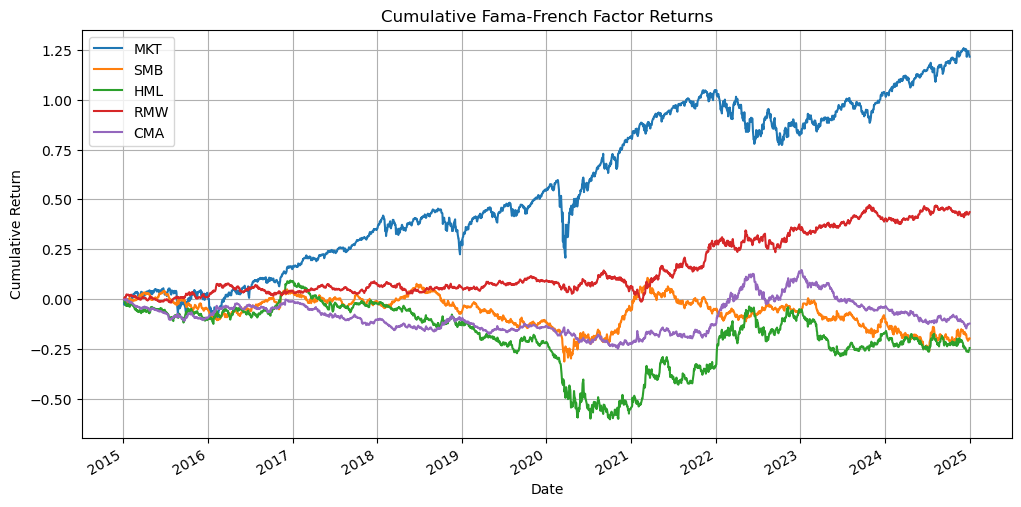

In [5]:
# Cummulative Portfolio Return Plot
df_cum = df.copy()
df_cum['Cumulative Portfolio Return'] = df_cum['Portfolio Return'].cumsum()
fig1 = px.line(df_cum, x=df_cum.index, y='Cumulative Portfolio Return',
               title='Cumulative Portfolio Return')
fig1.update_layout(xaxis_title='Date', yaxis_title='Cumulative Return')
fig1.show()

# Cummulative Factor Returns
df[['MKT', 'SMB', 'HML', 'RMW', 'CMA']].cumsum().plot(figsize=(12, 6), title='Cumulative Fama-French Factor Returns')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()

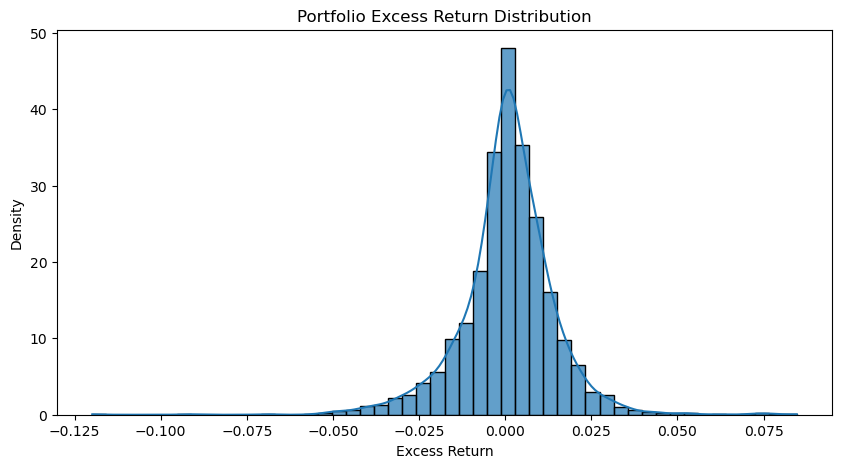

Skew: -0.37952777319618425
Kurtosis: 6.282682548417336


In [6]:
# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['Portfolio Excess Return'], bins=50, kde=True, stat='density', alpha=0.7)
plt.title('Portfolio Excess Return Distribution')
plt.xlabel('Excess Return')
plt.show()

skew = df['Portfolio Excess Return'].skew()
kurt = df['Portfolio Excess Return'].kurt()
print(f'Skew: {skew}')
print(f'Kurtosis: {kurt}')

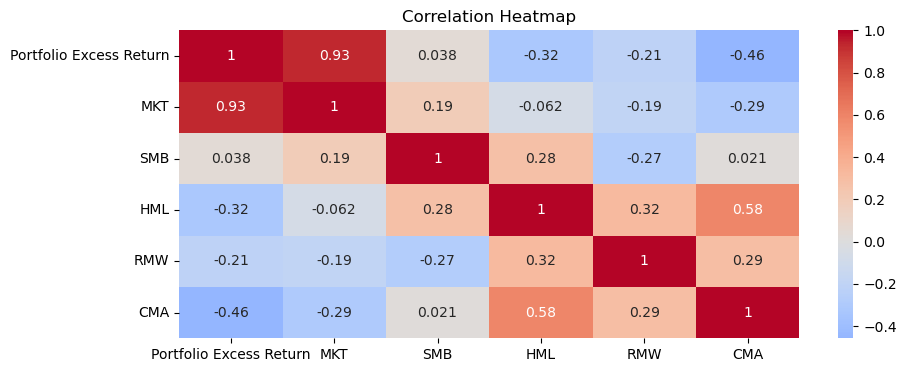

In [7]:
# Correlation heatmap
corr_matrix = df[['Portfolio Excess Return', 'MKT', 'SMB', 'HML', 'RMW', 'CMA']].corr()
plt.figure(figsize=(10, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

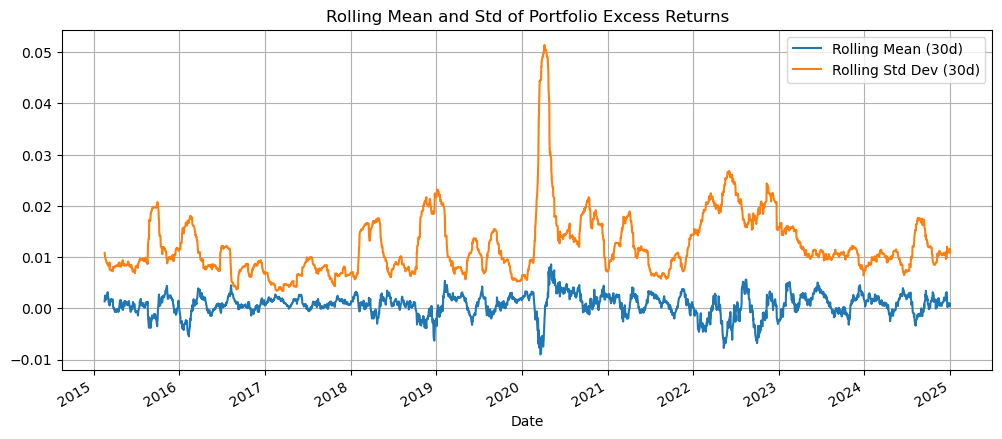

In [8]:
df['Portfolio Excess Return'].rolling(window=30).mean().plot(label='Rolling Mean (30d)', figsize=(12, 5))
df['Portfolio Excess Return'].rolling(window=30).std().plot(label='Rolling Std Dev (30d)')
plt.title('Rolling Mean and Std of Portfolio Excess Returns')
plt.legend()
plt.grid(True)
plt.show()

# Regression Analysis of Fama-French 5-Factor Model

In [9]:
# Assign X and y
X = df[['MKT', 'SMB', 'HML', 'RMW', 'CMA']]
y = df['Portfolio Excess Return']

# Add intercept to X
X = sm.add_constant(X)

# Fit model to OLS Regression
model = sm.OLS(y, X).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     Portfolio Excess Return   R-squared:                       0.949
Model:                                 OLS   Adj. R-squared:                  0.949
Method:                      Least Squares   F-statistic:                     9296.
Date:                     Tue, 11 Nov 2025   Prob (F-statistic):               0.00
Time:                             17:31:46   Log-Likelihood:                 10951.
No. Observations:                     2515   AIC:                        -2.189e+04
Df Residuals:                         2509   BIC:                        -2.185e+04
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

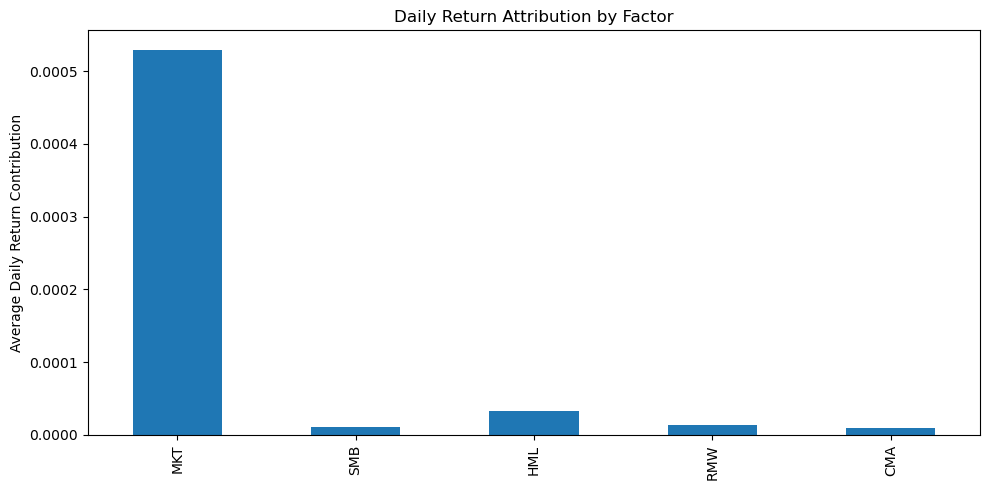

Total Explained Return (Daily): 0.000596
Alpha (Intercept): 0.000101


In [10]:
# Return Attribution: Factor Loading * Average Factor Return
betas = model.params[1:]
mean_factor_returns = X[betas.index].mean()

return_contrib = betas * mean_factor_returns

return_contrib.plot(kind='bar', figsize=(10, 5), title='Daily Return Attribution by Factor')
plt.ylabel('Average Daily Return Contribution')
plt.tight_layout()
plt.show()

explained_return = return_contrib.sum()
alpha = model.params['const']
print(f"Total Explained Return (Daily): {explained_return:.6f}")
print(f"Alpha (Intercept): {alpha:.6f}")

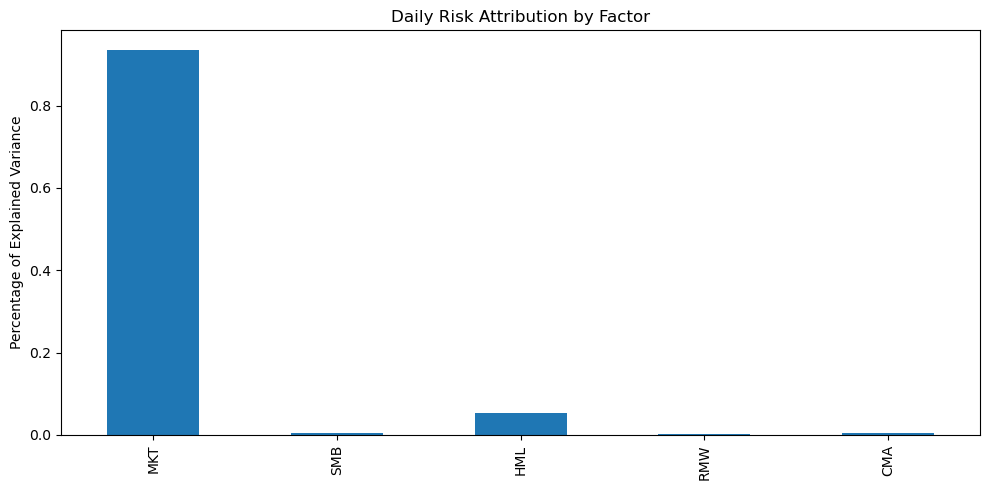

Risk Contribution (% of Explained Variance):
MKT    93.63
SMB     0.50
HML     5.24
RMW     0.10
CMA     0.53
dtype: float64


In [11]:
# Risk Attribution by Variance
factor_vars = X[betas.index].var()
risk_contrib = (betas ** 2) * factor_vars

total_risk = risk_contrib.sum()
risk_contrib_pct = risk_contrib / total_risk


risk_contrib_pct.plot(kind='bar', figsize=(10, 5), title='Daily Risk Attribution by Factor')
plt.ylabel('Percentage of Explained Variance')
plt.tight_layout()
plt.show()

print("Risk Contribution (% of Explained Variance):")
print((risk_contrib_pct * 100).round(2))